Advanced Tree Methods Decision Trees & Random Forests

Pruning (Cắt tỉa cây): Khắc phục vấn đề Overfitting.
    Concept: Dừng phát triển cây trước khi nó quá phức tạp bằng các ràng buộc cứng.

    Phương pháp 1: Các tham số giới hạn (Hyperparameters):
        · max_depth: Độ sâu tối đa (Thường dùng 3-10).
        . min_samples_split: Số mẫu tối thiểu để chia nhánh.
        . min_samples_leaf: Số mẫu tối thiểu tại lá.
        · max_leaf_nodes: Giới hạn tổng số node lá.
        Ưu điểm: Nhanh, đơn giản.
        Nhược điểm: Dễ bị 'Short-sighted' (dừng quá sớm, bỏ lỡ split tốt ở sâu hơn).

    Phương pháp 2: Post-pruning (Cost-Complexity)
        Xây dựng cây đầy đủ trước, sau đó cắt bỏ nhánh "đắt đỏ".
            Rα(T)=R(T) + α . |T|

                Rα(T): Tổng lỗi (Error Rate). Mức độ sai lệch của mô hình.

                α: Tham số phạt (Penalty) Trọng số kiểm soát mức độ cất tia.

                |T|: Độ phức tạp. Số lượng node lá trong cây.

            Vai trò của α
                Cơ chế:
                    α = 0: Giữ nguyên. cây (Overfitting).
                    α tăng: Cây bị cắt thương Cây bị cắt tỉa mạnh hơn.
                    α quá lớn: Cây quá đơn giản (Underfitting).

   So sánh Pre-pruning vs Post-pruning
   
    Pre-pruning
        Thời điểm: Trong khi xây dựng cây

        Tốc độ: Nhanh hơn

        Hiệu quả: Rủi ro dừng quá sớm (Short-sighted)

        Tham số chính: Nhiều (max_depth', 'min_samples' ... )

    Post-pruning
        Thời điểm: Sau khi cây đã hoàn thiện

        Tốc độ: Chậm hơn

        Hiệu quả: Thường cho kết quả tối ưu hơn

        Tham số chính: Duy nhất (α)

    => Kết luận: Post-pruning là lựa chọn đáng tin cậy hơn cho các bài toán yêu cầu độ chính xác cao.



Out-of-Bag (OOB): Tận dụng dữ liệu "bị bỏ quên"
    Cơ chế Bootstrap: Random Forest sử dụng lấy mẫu ngẫu nhiên có hoàn lại (sampling with replacement).
    Thống kê: Xác suất một mẫu không được chọn: P=(1 - 1/n)^n ~ (1/e) e ~ 36.8%
        Insight:
            Với mỗi cây, ~36.8% dữ liệu không được dùng để train. Tập này chính là OOB Samples dùng để validation.

    Quy trình tính toan OOB Error
        Identify: Xác định các cây không train trên mẫu xi.
        Predict: Dùng các cây này để dự đoán xi.
        Aggregate: Lấy đa số phiếu (Classification) hoặc trung bình (Regression).
        Evaluate: So sánh kết quả với nhãn thực tế (yi).

        OOB Error = 1/n ∑ 1[ŷ(oob) # y(true)]

    Khi nào dùng OOB vs. Cross-Validation?
        Ưu điểm của OOB
            · Tiết kiệm dữ liệu: Không
            cần tách riêng tập Validation
            (Quý giá khi dataset nhỏ).

            · Khách quan: Đánh giá
            tương đương k-fold
            Cross-Validation.

            · Tốc độ: Tỉnh toán song
            song ngay trong lúc train
            ("Free" computation).

            · Use case: Tinh chỉnh tham
            số nhanh, so sánh nội bộ
            Random Forest.

        Khi nào dùng Cross-Validation? (Use CV)
            ·   So sánh đa mô hình: Khi cần so sánh Random Forest với SVM, Logistic Regression, v.v.
            · Big Data: Khi dữ liệu rất lớn, CV cho kết quả ổn định hơn.

SHAP: Vén màn bí mật "Black Box"
    Vấn đề: Random Forest mạnh nhưng khó hiểu. Tại sao model đưa ra quyết định này?
    Giải pháp: SHAP (SHapley Additive exPlanations)
    Nguồn gốc: Dựa trên Lý thuyết trò chơi (Game Theory) - Chia phần thưởng công bằng cho các "người chơi" (features).

    Công thức Shapley Value
        𝜙i​=∑(𝑆⊆𝑁∖{i}) ((∣S∣! * (∣N∣−∣S∣−1)!)/|N|!) / ​[f(S∪{i})−f(S)]

        Prediction = Base Value + Sum(Feature Contributions)

        Meaning of symbols:
            𝜙𝑖 :  Shapley value of feature 
            N : set of all features
            𝑆 ⊆ 𝑁 ∖ {i}:  all subsets that do not contain feature 
            ∣S∣ : number of elements in subset S
            f(S) : model output using features in subset S
            f(S∪{i})−f(S) : marginal contribution of feature i

Isolation Forest: Ứng dụng phát hiện bất thường (Anomaly Detection).
    Tư duy ngược: Tìm cái 'Khác biệt' thay vì tìm 'Quy luật'

    Cốt lõi: Điểm bất thường (Anomaly) có tính chất "Ít xuất hiện" và "Khác biệt". Có 2 loại
        Khó bị cô lập -> Cần nhiều nhát cắt (Path dài).
        Dễ bị cô lập -> Cần ítnhát cắt (Path ngần).

    Tính toán Anomaly Score
        s(x,n)=2 - h(x) / c(n)

        · h(x): Độ dài đường đi trung bình (Path Length).
        · c(n): Hệ số chuẩn hóa.
        . Threshold Interpretation:
            · s ~ 1: Chắc chần là Anomaly (Path ngắn).
            . s ~ 0.5: Dữ liệu Normal.
            · s ~ 0: Rất an toàn (Sâu trong cụm).

Feature Selection: Tối ưu hóa dữ liệu đầu vào.




In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder



In [2]:
df = pd.read_csv('data_decision_tree_bt.csv')
df.head()



df_clean = df.dropna()
df_clean.isnull().sum()

# *** MANUAL ENCODER
# df_clean['DoHaiLong'] = (df_clean['DoHaiLong'] == 'Hài Lòng').astype(int) 

# *** LABEL ENCODER
# encoder = LabelEncoder()
# df_clean['LoaiKhachHang'] = encoder.fit_transform(df_clean['LoaiKhachHang'])
# df_clean['LoaiHinh'] = encoder.fit_transform(df_clean['LoaiHinh'])

# *** ONHOT ENCODER
df_cleaned_encoded = pd.get_dummies(df_clean, drop_first=True, dtype=int)
df_cleaned_encoded.columns
df_cleaned_encoded.head()


,TT,Tuoi,DoTrePhut,GheNgoi,ThucAn,GateLocation,DichVuGuiXe,BauKhongKhiTranDau,ChatLuongTranDau,TraiNghiemDatVeOnline,ChatLuongCacDichVuDiKem,DoAnToan,ThoiTiet,SuSachSe,FanDoiNha,ThietKeLoiDi,DoHaiLong_Không Hài Lòng,LoaiKhachHang_KH Trung Thành,LoaiHinh_Đi Cùng Gia Đình/Bạn Bè
0,0,29,15.0,5,5,4,5,2,5,1,5,5,4,5,4,5,1,0,1
1,1,44,0.0,4,5,5,3,1,4,3,4,3,3,2,3,5,1,1,1
2,2,48,0.0,5,2,1,4,2,5,4,5,4,4,4,4,3,0,1,1
3,3,45,0.0,5,5,4,3,2,4,3,5,5,5,5,5,3,0,0,1
4,4,49,0.0,4,4,2,4,1,5,4,5,4,1,4,2,4,1,1,0


In [3]:
y = df_cleaned_encoded['DoHaiLong_Không Hài Lòng']
x = df_cleaned_encoded.drop('DoHaiLong_Không Hài Lòng', axis=1)

features = x.columns.tolist()
print(len(features))
print(features)

18
['TT', 'Tuoi', 'DoTrePhut', 'GheNgoi', 'ThucAn', 'GateLocation', 'DichVuGuiXe', 'BauKhongKhiTranDau', 'ChatLuongTranDau', 'TraiNghiemDatVeOnline', 'ChatLuongCacDichVuDiKem', 'DoAnToan', 'ThoiTiet', 'SuSachSe', 'FanDoiNha', 'ThietKeLoiDi', 'LoaiKhachHang_KH Trung Thành', 'LoaiHinh_Đi Cùng Gia Đình/Bạn Bè']


1.0
0.8855746877339533
Tree depth:  36
Number of leaves:  8768
Number of alphas: 3790
Min alpha: 0.0
Max alpha: 0.09050214189143402
[0.00000000e+00 6.36816871e-06 6.56717398e-06 7.88060878e-06
 8.44350940e-06 8.61941585e-06 8.86568487e-06 9.09301013e-06
 9.27130444e-06 9.44031260e-06 9.63382730e-06 9.85076097e-06
 1.07532673e-05 1.17270964e-05 1.21917768e-05 1.30982646e-05
 1.31343480e-05 1.31343480e-05 1.37910654e-05 1.45041429e-05
 1.47761415e-05 1.50447986e-05 1.57612176e-05 1.60592238e-05
 1.64179350e-05 1.69386180e-05 1.75124639e-05 1.81860203e-05
 1.89063131e-05 1.99438687e-05 2.13433154e-05 2.28246858e-05
 2.43228666e-05 2.65970546e-05 2.95522829e-05 3.40522896e-05
 4.05157540e-05 5.11278822e-05 7.97180244e-05 1.57318972e-04
 1.28879127e-03]


<Figure size 1000x600 with 0 Axes>

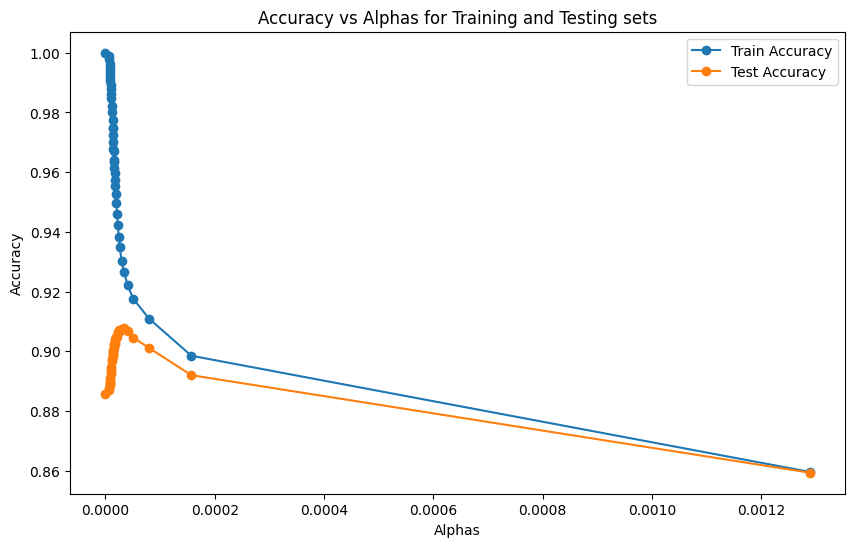

Best alpha: 0.00003
Max Test Accuracy:  0.9078371882264865
Tree depth at Best Alpha: 24


In [ ]:
# Xây dựng cây đầy đủ trước, sau đó cắt bỏ nhánh "đắt đỏ".
#     Rα(T)=R(T) + α . |T|

#         Rα(T): Tổng lỗi (Error Rate). Mức độ sai lệch của mô hình.

#         α: Tham số phạt (Penalty) Trọng số kiểm soát mức độ cất tia.

#         |T|: Độ phức tạp. Số lượng node lá trong cây.

#     Vai trò của α
#         Cơ chế:
#             α = 0: Giữ nguyên. cây (Overfitting).
#             α tăng: Cây bị cắt thương Cây bị cắt tỉa mạnh hơn.
#             α quá lớn: Cây quá đơn giản (Underfitting).

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

default_decission_tree = DecisionTreeClassifier(random_state=42)

default_decission_tree.fit(x_train, y_train)

train_accuracy = default_decission_tree.score(x_train, y_train)
test_accuracy = default_decission_tree.score(x_test, y_test)

print(train_accuracy)
print(test_accuracy)

print('Tree depth: ', default_decission_tree.get_depth())
print('Number of leaves: ', default_decission_tree.get_n_leaves())

# Prunning (Rα​(T)=R(T)+α∣T∣)
    # T = the tree

    # R(T) = total impurity of the leaves

    # |T| = number of leaves

    # α (ccp_alpha) = pruning strength
prunning_path = default_decission_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = prunning_path.ccp_alphas

print('Number of alphas:', len(ccp_alphas)) #3790
print('Min alpha:', ccp_alphas.min())
print('Max alpha:', ccp_alphas.max())

# get random alphas
n_alpha = 40

alphas = ccp_alphas[::max(1, len(ccp_alphas)//n_alpha)]
print(alphas)

# fit tree with alphas
train_scores = []
test_scores = []

for a in alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=a)
    tree.fit(x_train, y_train)
    train_scores.append(tree.score(x_train, y_train))
    test_scores.append(tree.score(x_test, y_test))

plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
plt.plot(alphas, train_scores, marker='o', label='Train Accuracy')
plt.plot(alphas, test_scores, marker='o', label='Test Accuracy')
plt.xlabel('Alphas')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Alphas for Training and Testing sets')
plt.legend()
plt.show()

# get max best alpha which has best accuracy
max_test_accuracy = max(test_scores)
best_alpha = alphas[test_scores.index(max_test_accuracy)]
print(f'Best alpha: {best_alpha :.5f}')
print('Max Test Accuracy: ', max_test_accuracy)

print(f'Tree depth at Best Alpha: {DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha).fit(x_train, y_train).get_depth()}')

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_tree.fit(x_train, y_train)
y_pred = best_tree.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Precision: {precision:.4f}')

Accuracy: 0.9078
F1 Score: 0.9078
Recall: 0.9078
Precision: 0.9078


In [6]:
# Out-of-Bag (OOB)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
rf_train_accuracy = rf.score(x_train, y_train)
rf_test_accuracy = rf.score(x_test, y_test)

print('Random forest train accuracy: ', rf_train_accuracy)
print('Random forest test accuracy: ', rf_test_accuracy)


rf_oob = RandomForestClassifier(random_state=42, oob_score=True, n_estimators=100)
rf_oob.fit(x_train, y_train)
print('Random forest OOB score: ', rf_oob.oob_score_)
print('Random forest OOB train accuracy: ', rf_oob.score(x_train, y_train))
print('Random forest OOB test accuracy: ', rf_oob.score(x_test, y_test))




Random forest train accuracy:  0.9999901492390287
Random forest test accuracy:  0.9179242680956696
Random forest OOB score:  0.9193813722110032
Random forest OOB train accuracy:  0.9999901492390287
Random forest OOB test accuracy:  0.9179242680956696


In [ ]:
oob_errors = []
n_estimators_range = range(10, 201, 10)

for n in n_estimators_range:
    rf_temp = RandomForestClassifier(random_state=42, oob_score=True, n_estimators=n)
    rf_temp.fit(x_train, y_train)
    oob_error = 1 - rf_temp.oob_score_
    oob_errors.append(oob_errors)

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, oob_errors, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('OOB Error')
plt.title('OOB Error vs Number of Estimators in Random Forest')
plt.show()

c:\Users\Ryan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Ryan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


c:\Users\Ryan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(500, 18, 2)
2


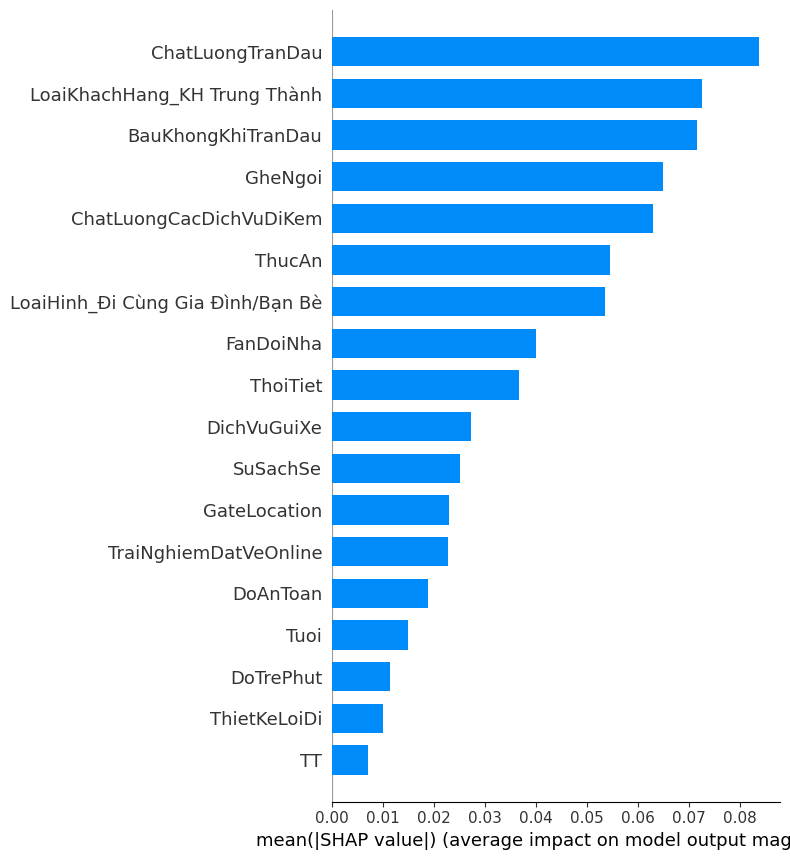

In [ ]:
# SHAP
import shap as sp
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

shape_explainer = sp.TreeExplainer(rf)

X_train_sample = x_train.sample(n=500, random_state=42)
shap_values = shape_explainer.shap_values(X_train_sample)
print(shap_values.shape)
shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
print(len(shap_values))
plt.figure(figsize=(10, 6))
sp.summary_plot(shap_values[0], X_train_sample, plot_type="bar", show=False)
plt.show()


Number of anomalies in training set:  1016


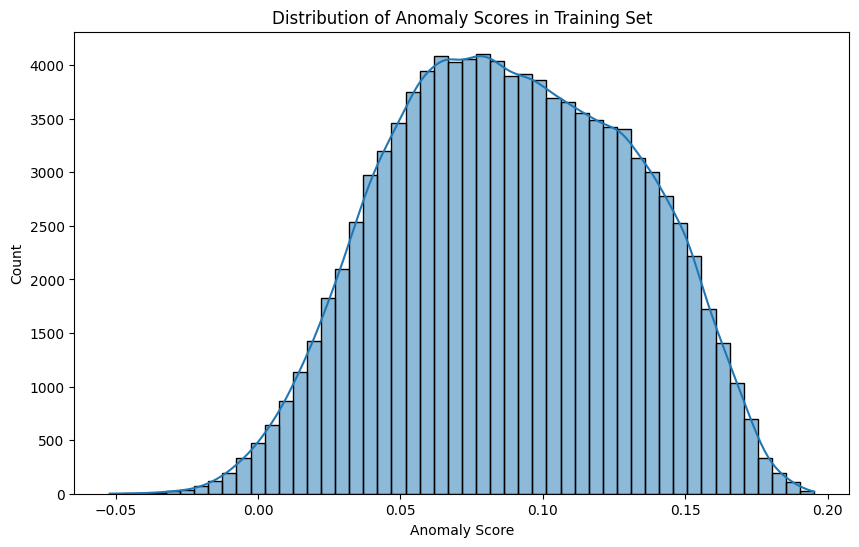

In [ ]:
#IsolationForest
# 
#  Tính toán Anomaly Score
# s(x,n)=2 - h(x) / c(n)

# · h(x): Độ dài đường đi trung bình (Path Length).
# · c(n): Hệ số chuẩn hóa.
# . Threshold Interpretation:
#     · s ~ 1: Chắc chần là Anomaly (Path ngắn).
#     . s ~ 0.5: Dữ liệu Normal.
#     · s ~ 0: Rất an toàn (Sâu trong cụm).

from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(random_state=42, contamination=0.01, n_estimators=100)
iso_forest.fit(x_train)
n_anomalies = iso_forest.predict(x_train)
print('Number of anomalies in training set: ', np.sum(n_anomalies == -1))

anomaly_scores = iso_forest.decision_function(x_train)

plt.figure(figsize=(10, 6))
sns.histplot(anomaly_scores, bins=50, kde=True)
plt.xlabel('Anomaly Score')
plt.title('Distribution of Anomaly Scores in Training Set')
plt.show()


In [9]:
n_anomalies

anomaly_bool = n_anomalies == -1

anomaly_bool

do_tre_mean_anomaly = x_train[anomaly_bool]['DoTrePhut'].mean()
print(do_tre_mean_anomaly)

do_tre_mean_normal = x_train[~anomaly_bool]['DoTrePhut'].mean()
print(do_tre_mean_normal)

17.513779527559056
4.851759719002179
